In [1]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_generator import *
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
DEVICE

device(type='mps')

In [ ]:
from matplotlib.pyplot import grid
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class SimplePolygonEnv(gym.Env):
    """Custom Environment that follows gymnasium interface"""
    
    def __init__(self, grid_dataset):
        super(SimplePolygonEnv, self).__init__()
        
        self.grid_dataset = grid_dataset # Pass your offline dataset here
        self.current_grid_idx = 0
        
        # Assume H=16, W=16 for this example. Change to your actual grid size.
        self.H, self.W = 16, 16 
        
        # ACTION SPACE: 4 Discrete Actions (0: Up, 1: Down, 2: Left, 3: Right)
        self.action_space = spaces.Discrete(4)
        self.action_mapping = {
            0: (-1, 0),  # Up
            1: (1, 0),   # Down
            2: (0, -1),  # Left
            3: (0, 1)    # Right
        }

        self.use_frontier_potential = False # Toggle for the global gravity reward
        
        # OBSERVATION SPACE: The exact 4-Channel tensor you feed your U-Net
        # Shape: (5, H, W), Values between 0.0 and 1.0
        self.observation_space = spaces.Box(
            low=0.0, high=np.inf, shape=(5, self.H, self.W), dtype=np.float32
        )
    
    def action_masks(self):
        """
        Returns a boolean array where True = Valid Action, False = Wall/Boundary.
        Order: [Up, Down, Left, Right] (matches your action_mapping)
        """
        mask = np.ones(4, dtype=bool)
        r, c = self.agent_pos
        
        for action_idx, (dr, dc) in self.action_mapping.items():
            nr, nc = r + dr, c + dc
            # If the neighbor is out of bounds OR is a wall, mask it out
            if not (0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0):
                mask[action_idx] = False
                
        return mask
    
    def _get_frontier_potential(self):
        """
        Calculates Manhattan distance to the nearest true frontier.
        Frontier: A known floor tile that orthogonally borders an unseen cell.
        """
        # 1. Identify Unseen cells
        unseen = (self.unseen_map == 1)
        
        # 2. Fast NumPy trick to find all cells that orthogonally border an unseen cell
        adj_unseen = np.zeros_like(unseen, dtype=bool)
        adj_unseen[:-1, :] |= unseen[1:, :]  # Check Up
        adj_unseen[1:, :] |= unseen[:-1, :]  # Check Down
        adj_unseen[:, :-1] |= unseen[:, 1:]  # Check Left
        adj_unseen[:, 1:] |= unseen[:, :-1]  # Check Right
        
        # 3. Apply your exact definition: Must be a floor (0), must be seen (0), and borders unseen
        is_known_floor = (self.grid == 0) & (self.unseen_map == 0)
        frontier_mask = is_known_floor & adj_unseen
        
        # Extract the coordinates of these specific frontier tiles
        frontier_coords = np.argwhere(frontier_mask)
        
        if len(frontier_coords) == 0:
            return 0 # Map is fully explored (or no frontiers exist)
            
        # 4. Calculate Manhattan distance from agent to all frontier tiles
        agent_r, agent_c = self.agent_pos
        distances = np.abs(frontier_coords[:, 0] - agent_r) + np.abs(frontier_coords[:, 1] - agent_c) + 1.0 # +1 to avoid division by zero and to give a small base potential even to adjacent frontiers
        
        total_potential = np.sum(1 / distances) # Closer frontiers contribute more to the potential
        return total_potential

    def _get_frontier_map(self):
        """
        Returns a binary map of the same size as the grid, where 1s indicate frontier tiles.
        Frontier: A known floor tile that orthogonally borders an unseen cell.
        """
        # 1. Identify Unseen cells
        unseen = (self.unseen_map == 1)
        
        # 2. Fast NumPy trick to find all cells that orthogonally border an unseen cell
        adj_unseen = np.zeros_like(unseen, dtype=bool)
        adj_unseen[:-1, :] |= unseen[1:, :]  # Check Up
        adj_unseen[1:, :] |= unseen[:-1, :]  # Check Down
        adj_unseen[:, :-1] |= unseen[:, 1:]  # Check Left
        adj_unseen[:, 1:] |= unseen[:, :-1]  # Check Right
        
        # 3. Apply your exact definition: Must be a floor (0), must be seen (0), and borders unseen
        is_known_floor = (self.grid == 0) & (self.unseen_map == 0)
        frontier_mask = is_known_floor & adj_unseen
        
        return frontier_mask.astype(np.float32) # Convert boolean mask to float32 for neural network compatibility

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # 1. Load a random grid from your dataset
        self.grid = self.grid_dataset[np.random.randint(len(self.grid_dataset))]
        
        # 2. Spawn agent on a random clear floor tile
        free_cells = np.argwhere(self.grid == 0)
        spawn_idx = np.random.choice(len(free_cells))
        self.agent_pos = tuple(free_cells[spawn_idx])
        self.path = [self.agent_pos]
        self.cells_revealed_per_step = []
        
        # 3. Initialize Memory Maps
        self.known_obstacles = np.zeros_like(self.grid, dtype=np.float32)
        self.unseen_map = np.ones_like(self.grid, dtype=np.float32)
        # --- NEW BREADCRUMB MEMORY ---
        self.visit_count = np.zeros_like(self.grid, dtype=np.float32)
        
        self.step_count = 0
        self.max_steps = 256
        
        # 4. Generate initial observation
        obs = self._get_obs()
        
        if self.use_frontier_potential:
            self.previous_potential = self._get_frontier_potential() # For the global gravity reward
        # Gymnasium v0.26+ requires returning (observation, info_dict)
        return obs, {}

    def step(self, action):
        self.step_count += 1
        
        if isinstance(action, np.ndarray):
            action = action.item()
        # 1. Attempt to move the agent
        dr, dc = self.action_mapping[action]
        r, c = self.agent_pos
        nr, nc = r + dr, c + dc
        
        reward = -0.1 # Base time penalty (punishes dithering/hesitation)

         # 5. Check Termination Conditions
        terminated = False
        truncated = False
        
        # 2. Check collision
        if 0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0:
            # Valid move
            self.agent_pos = (nr, nc)
           
            self.path.append(self.agent_pos)
            
            # --- THE REVISIT PENALTY ---
            # If we have been here before, penalize it heavily. 
            # 1st visit = 0 penalty. 2nd visit = -0.1. 3rd visit = -0.2. etc.
            visits = self.visit_count[nr, nc]
            reward -= ((visits ** 2) * 0.9) #exponential penalty for repeated visits
            self.visit_count[nr, nc] += 1

            
            # ---------------------------
        else:
            reward -= 10 # Wall collision
            self.path.append(self.agent_pos) # Even if we hit a wall, we "visit" that cell for LOS purposes
            path_length_untill_now = len(self.path)
            self.path.extend((self.max_steps - path_length_untill_now) * [self.agent_pos]) # Pad the path to max length to avoid issues in the replay buffer
            self.step_count = self.max_steps # Force end of episode
            terminated = True

        # 3. Update Maps & Calculate New Information
        previous_unseen_count = self.unseen_map.sum()
        obs = self._get_obs() # This calls your LOS and Grazing functions
        current_unseen_count = self.unseen_map.sum()
        
        
        # 4. Reward Shaping: Reward the agent for discovering new floor
        cells_revealed = previous_unseen_count - current_unseen_count
        if cells_revealed >= 0:
            reward += cells_revealed * 5.0
            self.cells_revealed_per_step.append(cells_revealed)

        if self.use_frontier_potential:
            # --- THE GLOBAL GRAVITY REWARD ---
            current_potential = self._get_frontier_potential()
            # Did the global pull get stronger (we moved closer) or weaker (we moved away)?
            potential_change = current_potential - self.previous_potential
            # potential_change is POSITIVE if we got closer to the fog mass (Good)
            # potential_change is NEGATIVE if we moved further away (Bad)
            reward += (potential_change * 10) # You may need to tune this multiplier!
            
            self.previous_potential = current_potential
            # ---------------------------------
            
        # 2. The Exact Termination Condition
        unseen_floor_count = np.sum(self.unseen_map[self.grid == 0])
        
        # Did we explore everything?
        if unseen_floor_count == 0:  
            terminated = True
            # --- THE SPEED BONUS ---
            # Max possible steps is self.max_steps. We reward the agent for unused time.
            steps_remaining = self.max_steps - self.step_count
            
            # Base completion (+10) plus a scaling bonus for speed (e.g., +0.1 per saved step)
            speed_bonus = steps_remaining * 0.1
            reward += (50.0 + speed_bonus)
            
        # Did we run out of time? (e.g., trapped in a loop)
        if self.step_count >= self.max_steps:
            truncated = True

        return obs, float(reward), terminated, truncated, {"path": self.path, "cells_revealed": self.cells_revealed_per_step, "reward": reward}

    def _get_obs(self):
        """Builds the 3-channel state tensor identically to your U-Net"""
        agent_layer = np.zeros_like(self.grid, dtype=np.float32)
        agent_layer[self.agent_pos] = 1.0
        
        # NOTE: Call your exact LOS functions here
        expanded_los_ = get_LOS4_visibility_map(self.grid, self.path)
        expanded_los = apply_grazing_los(self.grid, expanded_los_)
        
        # For boilerplate, assuming expanded_los is calculated:
        self.unseen_map[expanded_los == 1] = 0.0
        visible_walls = expanded_los & (self.grid == 1)
        self.known_obstacles[visible_walls] = 1.0
        self.frontier_map = self._get_frontier_map() # Get the frontier map for the current state

        # Normalize the visit count so the neural network can read it safely [0.0 to 1.0]
        # (Assuming it rarely visits a single cell more than 10 times if exploring optimally)
        visit_heatmap = self.visit_count / 10.0
        
        state_tensor = np.stack([
            self.known_obstacles, 
            agent_layer, 
            self.unseen_map, 
            visit_heatmap, # <-- The new 4th channel
            self.frontier_map # <-- The new 5th channel
        ], axis=0)
        
        return state_tensor

In [4]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from autoregressive_unet import ResidualConv

class CustomGridCNN(BaseFeaturesExtractor):
    """
    A custom CNN tailored for tiny 16x16 grids.
    """

    def _get_coord_channels(self, batch_size, height, width, device):
        """Generates normalized coordinate channels"""
        y_coords = torch.linspace(-1, 1, steps=height, device=device).view(1, 1, height, 1).expand(batch_size, 1, height, width)
        x_coords = torch.linspace(-1, 1, steps=width, device=device).view(1, 1, 1, width).expand(batch_size, 1, height, width)
        return x_coords, y_coords
    
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 512):
        super(CustomGridCNN, self).__init__(observation_space, features_dim)
        
        n_input_channels = observation_space.shape[0] + 2  # Original channels + 2 for coordinates
        
        self.cnn = nn.Sequential(
            # 16x16 -> 16x16
            nn.Conv2d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # 16x16 -> 8x8
            nn.MaxPool2d(2),
            # 8x8 -> 8x8
            nn.Conv2d(32, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 8x8 -> 4x4
            nn.MaxPool2d(2),
            nn.Flatten(),
        )

        # Compute shape by doing one forward pass with dummy data
        with torch.no_grad():
            dummy_tensor = torch.as_tensor(observation_space.sample()[None]).float()
            batch_size, _, height, width = dummy_tensor.shape
            device = dummy_tensor.device
            x_coords, y_coords = self._get_coord_channels(batch_size, height, width, device)
            dummy_tensor = torch.cat([dummy_tensor, x_coords, y_coords], dim=1)
            n_flatten = self.cnn(dummy_tensor).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim), 
            nn.ReLU()
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        batch_size, _, height, width = observations.shape
        device = observations.device
        x_coords, y_coords = self._get_coord_channels(batch_size, height, width, device)
        observations_ = torch.cat([observations, x_coords, y_coords], dim=1)
        return self.linear(self.cnn(observations_))

Generated Grid:


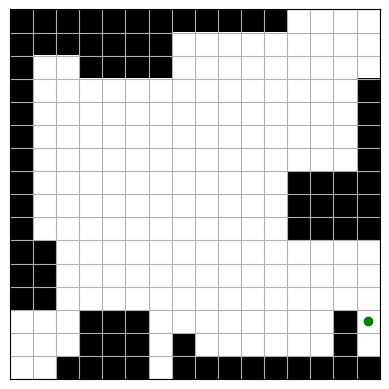

In [5]:
# Generate a random grid
gen = WRPDataGenerator(16, 16)
# grid, start = gen.generate_valid_grid(density=5)
grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


In [6]:
N = 20_000
grid_dataset = []
for _i in range(N):
    grid, start = gen.generate_simple_polygon_grid()
    grid_dataset.append(grid)
np.array(grid_dataset).shape

(20000, 16, 16)

In [7]:
# import stable_baselines3
# stable_baselines3.common.env_checker.check_env(SimplePolygonEnv(grid_dataset=grid_dataset), warn=True)

In [8]:
# from stable_baselines3 import PPO

# # Tell SB3 to use your CustomGridCNN instead of NatureCNN
# policy_kwargs = dict(
#     features_extractor_class=CustomGridCNN,
#     features_extractor_kwargs=dict(features_dim=512),
# )

# env = SimplePolygonEnv(grid_dataset=grid_dataset)

# print("Starting PPO Training with Custom CNN...")
# model = PPO("CnnPolicy", env, policy_kwargs=policy_kwargs, verbose=1, learning_rate=0.0003)

# model.learn(total_timesteps=5_000_000, progress_bar=True, log_interval=100)

In [9]:
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.maskable.evaluation import evaluate_policy
from sb3_contrib.common.wrappers import ActionMasker
# 1. Initialize the environment
env = SimplePolygonEnv(grid_dataset=grid_dataset)
env = ActionMasker(env, action_mask_fn=lambda env: env.action_masks())
policy_kwargs = dict(
    features_extractor_class=CustomGridCNN,
    features_extractor_kwargs=dict(features_dim=512),
)
# 2. Setup the Maskable PPO model
# Note: Use 'MultiInputPolicy' if you have complex obs, 
# or 'CnnPolicy' for your current grid setup.
model = MaskablePPO(
    "CnnPolicy", 
    env, 
    policy_kwargs=policy_kwargs, 
    verbose=1, 
    learning_rate=0.0003, 
)
# 3. Train
model.learn(total_timesteps=500_000, log_interval=10, progress_bar=True)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Output()

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 246        |
|    ep_rew_mean          | -3.28e+03  |
| time/                   |            |
|    fps                  | 207        |
|    iterations           | 10         |
|    time_elapsed         | 98         |
|    total_timesteps      | 20480      |
| train/                  |            |
|    approx_kl            | 0.01106735 |
|    clip_fraction        | 0.0846     |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.27      |
|    explained_variance   | 0.0929     |
|    learning_rate        | 0.0003     |
|    loss                 | 3.37e+04   |
|    n_updates            | 90         |
|    policy_gradient_loss | -0.00757   |
|    value_loss           | 1.19e+05   |
----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 251          |
|    ep_rew_mean          | -2.93e+03    |
| time/                   |              |
|    fps                  | 189          |
|    iterations           | 20           |
|    time_elapsed         | 215          |
|    total_timesteps      | 40960        |
| train/                  |              |
|    approx_kl            | 0.0054753856 |
|    clip_fraction        | 0.0668       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.18        |
|    explained_variance   | 0.055        |
|    learning_rate        | 0.0003       |
|    loss                 | 8.19e+04     |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00244     |
|    value_loss           | 4.53e+05     |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 249         |
|    ep_rew_mean          | -2.22e+03   |
| time/                   |             |
|    fps                  | 182         |
|    iterations           | 30          |
|    time_elapsed         | 336         |
|    total_timesteps      | 61440       |
| train/                  |             |
|    approx_kl            | 0.010060157 |
|    clip_fraction        | 0.107       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.24       |
|    explained_variance   | 0.358       |
|    learning_rate        | 0.0003      |
|    loss                 | 3.23e+04    |
|    n_updates            | 290         |
|    policy_gradient_loss | -0.0039     |
|    value_loss           | 5.67e+04    |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 237         |
|    ep_rew_mean          | -958        |
| time/                   |             |
|    fps                  | 183         |
|    iterations           | 200         |
|    time_elapsed         | 2227        |
|    total_timesteps      | 409600      |
| train/                  |             |
|    approx_kl            | 0.009386577 |
|    clip_fraction        | 0.103       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.25       |
|    explained_variance   | 0.804       |
|    learning_rate        | 0.0003      |
|    loss                 | 215         |
|    n_updates            | 1990        |
|    policy_gradient_loss | -0.00565    |
|    value_loss           | 1.82e+03    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 240         |
|    ep_rew_mean          | -1.43e+03   |
| time/                   |             |
|    fps                  | 184         |
|    iterations           | 210         |
|    time_elapsed         | 2337        |
|    total_timesteps      | 430080      |
| train/                  |             |
|    approx_kl            | 0.008310637 |
|    clip_fraction        | 0.0859      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.2        |
|    explained_variance   | 0.761       |
|    learning_rate        | 0.0003      |
|    loss                 | 9.65e+03    |
|    n_updates            | 2090        |
|    policy_gradient_loss | -0.00304    |
|    value_loss           | 2.53e+04    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 234         |
|    ep_rew_mean          | -1.23e+03   |
| time/                   |             |
|    fps                  | 184         |
|    iterations           | 220         |
|    time_elapsed         | 2446        |
|    total_timesteps      | 450560      |
| train/                  |             |
|    approx_kl            | 0.007484275 |
|    clip_fraction        | 0.1         |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.21       |
|    explained_variance   | 0.592       |
|    learning_rate        | 0.0003      |
|    loss                 | 5.99e+03    |
|    n_updates            | 2190        |
|    policy_gradient_loss | -0.00126    |
|    value_loss           | 1.12e+04    |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 240          |
|    ep_rew_mean          | -8.53e+03    |
| time/                   |              |
|    fps                  | 184          |
|    iterations           | 230          |
|    time_elapsed         | 2555         |
|    total_timesteps      | 471040       |
| train/                  |              |
|    approx_kl            | 0.0089992955 |
|    clip_fraction        | 0.0645       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.24        |
|    explained_variance   | 0.826        |
|    learning_rate        | 0.0003       |
|    loss                 | 980          |
|    n_updates            | 2290         |
|    policy_gradient_loss | -0.00617     |
|    value_loss           | 4.16e+03     |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 238         |
|    ep_rew_mean          | -8.59e+03   |
| time/                   |             |
|    fps                  | 184         |
|    iterations           | 240         |
|    time_elapsed         | 2668        |
|    total_timesteps      | 491520      |
| train/                  |             |
|    approx_kl            | 0.009055583 |
|    clip_fraction        | 0.0893      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.2        |
|    explained_variance   | 0.74        |
|    learning_rate        | 0.0003      |
|    loss                 | 890         |
|    n_updates            | 2390        |
|    policy_gradient_loss | 0.00177     |
|    value_loss           | 3.02e+03    |
-----------------------------------------


In [20]:
import numpy as np
from stable_baselines3 import PPO

# # 1. Load the RAW test dataset (Ground truth grids, not X_test/y_test tensors)
# # Assuming you have 750 raw test grids based on your previous data
# raw_test_grids = np.load("data/raw_simple_polygons_test.npy") 

# 2. Initialize the environment with the TEST data
eval_env = SimplePolygonEnv(grid_dataset=grid_dataset)

# 3. Load the trained model
# Replace with your actual saved model path
# model = PPO.load("ppo_baseline_agent")

ppo_path_lengths = []
success_count = 0

print(f"Evaluating PPO Baseline on {len(grid_dataset)} test environments...")

for i in range(len(grid_dataset)):
    # Force the environment to use the specific test grid sequentially
    eval_env.grid_dataset = [grid_dataset[i]] 
    obs, info = eval_env.reset()
    
    done = False
    steps_taken = 0
    
    while not done:
        # deterministic=True forces the agent to take the action with the highest probability
        action_mask = get_action_masks(eval_env)
        action, _states = model.predict(obs, deterministic=True, action_masks=action_mask)
        
        obs, reward, terminated, truncated, info = eval_env.step(action.item())
        steps_taken += 1
        
        if terminated or truncated:
            done = True
            ppo_path_lengths.append(steps_taken)
            if terminated:
                success_count += 1
            
    if (i + 1) % 50 == 0:
        print(f"Evaluated {i + 1}/{len(grid_dataset)} grids...")

# --- THE FINAL METRICS ---
print("\n--- PPO Baseline Results ---")
print(f"Total Successes (Explored 100%): {success_count} / {len(grid_dataset)}")
print(f"Success Rate: {(success_count / len(grid_dataset)) * 100:.2f}%")
print(f"Average Path Length (including timeouts): {np.mean(ppo_path_lengths):.2f}")

Evaluating PPO Baseline on 10000 test environments...
Evaluated 50/10000 grids...
Evaluated 100/10000 grids...


KeyboardInterrupt: 

Agent failed to explore the entire grid within the step limit.


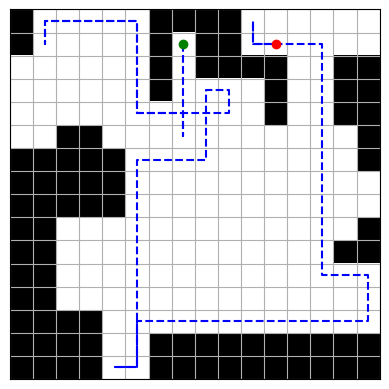

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO
eval_env = SimplePolygonEnv(grid_dataset=grid_dataset)
rnd = np.random.randint(len(grid_dataset))

# Load a single grid for visualization
eval_env.grid_dataset = [grid_dataset[rnd]] 
obs, info = eval_env.reset()
grid = eval_env.grid

done = False
while not done:
    action_mask = get_action_masks(eval_env)
    # print("Action Mask:", action_mask)
    action, _states = model.predict(obs, deterministic=True, action_masks=action_mask)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    if terminated or truncated:
        done = True
        if terminated:
            print("Agent successfully explored the entire grid!")
        else:
            print("Agent failed to explore the entire grid within the step limit.")

# Extract the path it took
path = info['path']

plot_path(grid, path)

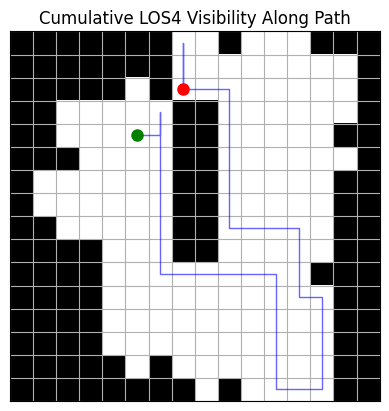

In [12]:
plot_visibility(grid, path)

In [13]:
path

[(np.int64(4), np.int64(5)),
 (np.int64(4), np.int64(6)),
 (np.int64(3), np.int64(6)),
 (np.int64(4), np.int64(6)),
 (np.int64(3), np.int64(6)),
 (np.int64(4), np.int64(6)),
 (np.int64(3), np.int64(6)),
 (np.int64(4), np.int64(6)),
 (np.int64(5), np.int64(6)),
 (np.int64(6), np.int64(6)),
 (np.int64(7), np.int64(6)),
 (np.int64(8), np.int64(6)),
 (np.int64(9), np.int64(6)),
 (np.int64(10), np.int64(6)),
 (np.int64(10), np.int64(7)),
 (np.int64(10), np.int64(8)),
 (np.int64(10), np.int64(9)),
 (np.int64(10), np.int64(10)),
 (np.int64(10), np.int64(11)),
 (np.int64(11), np.int64(11)),
 (np.int64(12), np.int64(11)),
 (np.int64(13), np.int64(11)),
 (np.int64(14), np.int64(11)),
 (np.int64(15), np.int64(11)),
 (np.int64(15), np.int64(12)),
 (np.int64(15), np.int64(13)),
 (np.int64(14), np.int64(13)),
 (np.int64(15), np.int64(13)),
 (np.int64(14), np.int64(13)),
 (np.int64(15), np.int64(13)),
 (np.int64(14), np.int64(13)),
 (np.int64(15), np.int64(13)),
 (np.int64(14), np.int64(13)),
 (np.in

In [79]:
len(path)

256

In [30]:
info["reward"]

np.float64(-10.1)

In [31]:
info["cells_revealed"]

[np.float32(15.0),
 np.float32(20.0),
 np.float32(12.0),
 np.float32(12.0),
 np.float32(4.0)]

In [85]:
len(info["cells_revealed"])
path[:23]

[(np.int64(13), np.int64(1)),
 (np.int64(13), np.int64(2)),
 (np.int64(13), np.int64(3)),
 (np.int64(13), np.int64(4)),
 (np.int64(13), np.int64(5)),
 (np.int64(13), np.int64(6)),
 (np.int64(13), np.int64(7)),
 (np.int64(13), np.int64(8)),
 (np.int64(13), np.int64(9)),
 (np.int64(13), np.int64(10)),
 (np.int64(13), np.int64(11)),
 (np.int64(13), np.int64(12)),
 (np.int64(12), np.int64(12)),
 (np.int64(11), np.int64(12)),
 (np.int64(10), np.int64(12)),
 (np.int64(9), np.int64(12)),
 (np.int64(8), np.int64(12)),
 (np.int64(7), np.int64(12)),
 (np.int64(6), np.int64(12)),
 (np.int64(5), np.int64(12)),
 (np.int64(4), np.int64(12)),
 (np.int64(3), np.int64(12)),
 (np.int64(3), np.int64(12))]